# Phase 7: Model Evaluation and Comparison

In this phase, I will compare the performance of the models built so far.

The main goals of this phase are:

- Load the MNIST dataset
- Recreate and train the models if needed
- Compare model accuracies
- Build a confusion matrix
- Identify incorrect predictions
- Understand which digits are most often confused
- Summarize the model performance clearly for the final GitHub README

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

In [3]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

In [4]:
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

x_train_cnn = x_train_norm.reshape(-1, 28, 28, 1)
x_test_cnn = x_test_norm.reshape(-1, 28, 28, 1)

In [5]:
cnn_model = Sequential([
    Conv2D(32, (3, 3), activation="relu", input_shape=(28, 28, 1)),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(64, activation="relu"),
    Dense(10, activation="softmax")
])

c:\Users\User\Desktop\handwritten-digit-recognition\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [6]:
cnn_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [7]:
cnn_history = cnn_model.fit(
    x_train_cnn,
    y_train,
    epochs=5,
    validation_split=0.2
)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9413 - loss: 0.1978 - val_accuracy: 0.9758 - val_loss: 0.0823
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9805 - loss: 0.0656 - val_accuracy: 0.9797 - val_loss: 0.0698
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9866 - loss: 0.0428 - val_accuracy: 0.9808 - val_loss: 0.0645
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9909 - loss: 0.0314 - val_accuracy: 0.9843 - val_loss: 0.0568
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9925 - loss: 0.0226 - val_accuracy: 0.9838 - val_loss: 0.0592


In [9]:
cnn_test_loss, cnn_test_accuracy = cnn_model.evaluate(x_test_cnn, y_test)

print("CNN test loss:", cnn_test_loss)
print("CNN test accuracy:", cnn_test_accuracy)
print("CNN test accuracy (%):", cnn_test_accuracy * 100)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9864 - loss: 0.0469
CNN test loss: 0.046920180320739746
CNN test accuracy: 0.9864000082015991
CNN test accuracy (%): 98.64000082015991


In [10]:

cnn_y_prob = cnn_model.predict(x_test_cnn)
cnn_y_pred = np.argmax(cnn_y_prob, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


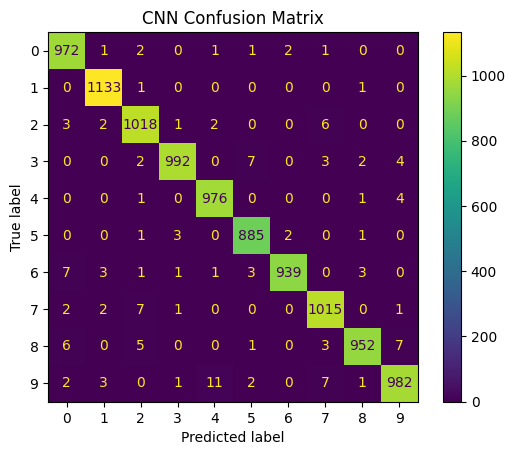

In [11]:
cm = confusion_matrix(y_test, cnn_y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("CNN Confusion Matrix")
plt.show()

In [12]:
print(classification_report(y_test, cnn_y_pred))

              precision    recall  f1-score   support

           0       0.98      0.99      0.99       980
           1       0.99      1.00      0.99      1135
           2       0.98      0.99      0.98      1032
           3       0.99      0.98      0.99      1010
           4       0.98      0.99      0.99       982
           5       0.98      0.99      0.99       892
           6       1.00      0.98      0.99       958
           7       0.98      0.99      0.98      1028
           8       0.99      0.98      0.98       974
           9       0.98      0.97      0.98      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



In [13]:
incorrect_indices = np.where(y_test != cnn_y_pred)[0]

print("Number of incorrect predictions:", len(incorrect_indices))
print("First 10 incorrect indices:")
print(incorrect_indices[:10])

Number of incorrect predictions: 136
First 10 incorrect indices:
[ 18  92 115 321 340 445 448 495 582 619]


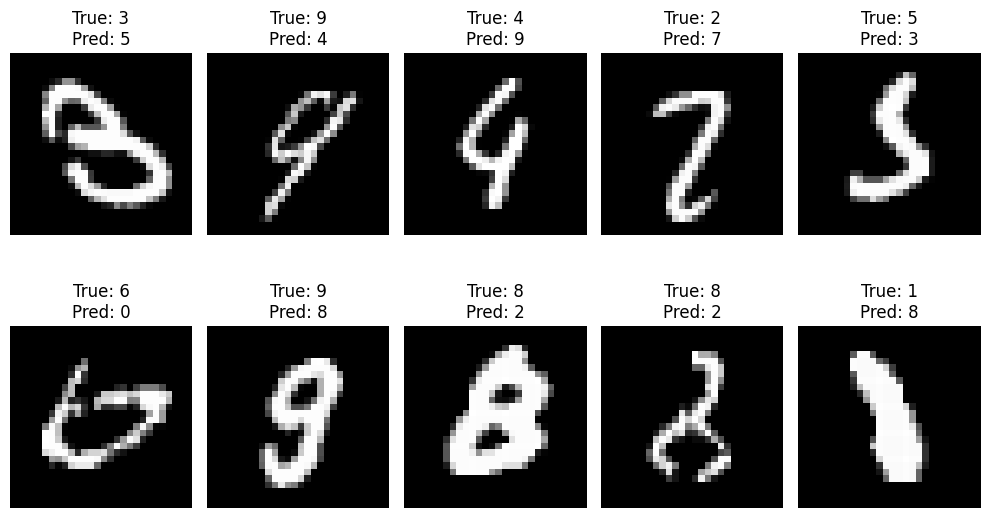

In [14]:
plt.figure(figsize=(10, 6))

for i in range(10):
    index = incorrect_indices[i]
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_test[index], cmap="gray")
    plt.title(f"True: {y_test[index]}\nPred: {cnn_y_pred[index]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [15]:
errors = []

for true_digit in range(10):
    for predicted_digit in range(10):
        if true_digit != predicted_digit:
            count = cm[true_digit, predicted_digit]
            if count > 0:
                errors.append((true_digit, predicted_digit, count))

errors_sorted = sorted(errors, key=lambda x: x[2], reverse=True)

print("Top 10 most common confusions:")
for true_digit, predicted_digit, count in errors_sorted[:10]:
    print(f"True {true_digit} predicted as {predicted_digit}: {count} times")

Top 10 most common confusions:
True 9 predicted as 4: 11 times
True 3 predicted as 5: 7 times
True 6 predicted as 0: 7 times
True 7 predicted as 2: 7 times
True 8 predicted as 9: 7 times
True 9 predicted as 7: 7 times
True 2 predicted as 7: 6 times
True 8 predicted as 0: 6 times
True 8 predicted as 2: 5 times
True 3 predicted as 9: 4 times


## Confusion Matrix and Error Analysis

The confusion matrix helps evaluate how well the CNN classifies each digit from 0 to 9.

In the confusion matrix:

- Rows represent the true labels
- Columns represent the predicted labels
- Values on the diagonal represent correct predictions
- Values outside the diagonal represent mistakes

The incorrect prediction examples help visually understand where the model struggles.  
Some errors happen because certain handwritten digits can look similar, such as:

- 4 and 9
- 3 and 5
- 7 and 9
- 2 and 8

This analysis is useful because accuracy alone does not show which specific classes the model confuses.

## Phase 7 Summary: Model Evaluation and Comparison

In this phase, I evaluated the CNN model more deeply using performance metrics and error analysis.

### Completed Tasks

- Loaded the MNIST dataset
- Preprocessed the images for CNN input
- Recreated and trained the CNN model
- Evaluated the CNN on the test set
- Generated CNN predictions for the test images
- Created a confusion matrix
- Printed a classification report
- Found the incorrect predictions
- Visualized examples of incorrect predictions
- Identified the most common digit confusions

### Key Observation

The CNN performs well on the MNIST test set, but some errors still occur when handwritten digits look visually similar.

The confusion matrix and incorrect prediction examples help explain the model’s mistakes more clearly than accuracy alone.

This analysis is important for understanding model behavior and preparing a professional final project summary for GitHub.